# Hands on with the Federalist Papers

Peter Ralph  
2026-02-04

# The Federalist Papers

## 

From the [Library of
Congress](https://guides.loc.gov/federalist-papers/full-text):

> The Federalist, commonly referred to as the Federalist Papers, is a
> series of 85 essays written by Alexander Hamilton, John Jay, and James
> Madison between October 1787 and May 1788. The essays were published
> anonymously, under the pen name “Publius,” in various New York state
> newspapers of the time.

## 

<figure>
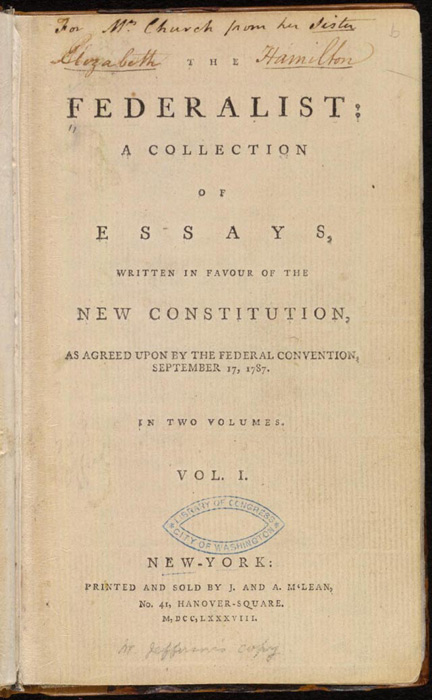
<figcaption aria-hidden="true">image of the cover</figcaption>
</figure>

*from Wikimedia*

## A mystery

Of 85 essays,

-   five were written by John Jay
-   three were written by Alexander Hamilton and James Madison together
-   15 were written by James Madison
-   51 were written by Alexander Hamilton
-   **but** three were claimed\* by both Madison and Hamilton

$^*$ in Hamilton’s case, in a list written two days before his death by
duel.

## Mosteller and Wallace (1963)

<figure>
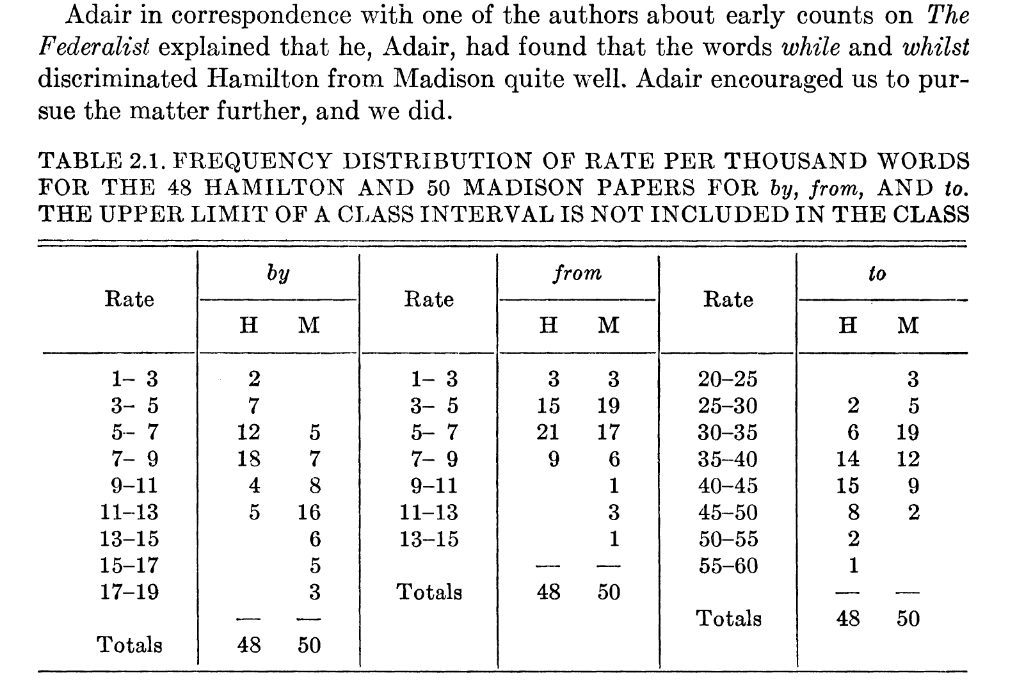
<figcaption aria-hidden="true">Table 2.1 of counts of ‘by’, ‘from’, and
‘to’, from Mosteller and Wallace</figcaption>
</figure>

## The results (roughly)

> Alexander joins forces with James Madison and John Jay To write a
> series of essays defending the new United States Constitution,
> entitled The Federalist Papers. The plan was to write a total of 25
> essays, the work Divided evenly among the three men. In the end, they
> wrote eighty-five essays in the span of six months. John Jay got sick
> after writing five James Madison wrote twenty-nine. Hamilton wrote the
> other fifty-one!

*Miranda, 2015*

## 

Mosteller and Wallace took a very hands-on and guided approach, counting
numbers of certain ‘filler’ words per block of 200 words:

> The words in an article were typed one word per line on a long paper
> tape, like adding machine tape. Then with scissors the tape was cut
> into slips, one word per slip . … When the counting was going on, if
> someone opened the door, slips of paper would fly about the room.

*Mosteller, 2010, quoted in [Text As
Data](https://press.princeton.edu/books/hardcover/9780691207544/text-as-data)*

## An exploratory approach

We’ll start with some exploration. A knee-jerk response to this question
(“who wrote these eleven papers”) might be: “hey let’s do dimension
reduction and see if the authors cluster”.

What do you think about this?

-   If the authors *do* cluster, why do you think this would happen?
    (i.e., where’s the signal for this coming from?)
-   If the authors *do* cluster, then does this give a good answer to
    the question?
-   Are there ways that this might mislead us?
-   What’s a more direct way you might answer the question?

# Let’s have a look

## set-up

In [ ]:
import json, re
import pandas as pd
import numpy as np
import plotnine as p9
import scipy
import sklearn.decomposition, sklearn.manifold

## The data

You can get the data from this file:
[data/federalist.json](../data/federalist.json). It is a text file,
where each line is a JSON entry, containing: `author`, `text`, `date`,
`title`, `paper_id`, and `venue`.

In [ ]:
with open("data/federalist.json", 'r') as f:
    text = [json.loads(line) for line in f]

info = pd.DataFrame(
    { k: [t[k] for t in text] for k in ['author', 'date', 'title', 'paper_id', 'venue']}
).assign(length = [len(t['text'].split(" ")) for t in text])
info

## What’s the plan?

1.  look at, and clean the data
2.  do PCA on the word count matrix
3.  think about the results
4.  adjust how we’re doing the PCA and iterate

## Cleaning:

The [re.sub](https://docs.python.org/3/library/re.html#re.sub) function
will be useful.

In [ ]:
def clean(t):
    return t

## Counting:

Once it’s cleaned, let’s count:

In [ ]:
from collections import Counter

words = np.unique(" ".join([clean(t['text']) for t in text]).split(" "))

def tabwords(x, words):
    d = Counter(x.split(" "))
    out = np.array([d[w] for w in words])
    return out

wordmat = np.array([tabwords(clean(t['text']), words) for t in text])

## PCA

Let’s do it “by hand” with SVD:

In [ ]:
x = wordmat

pcs, evals, evecs = scipy.sparse.linalg.svds(x, k=4)
eord = np.argsort(evals)[::-1]
evals = evals[eord]
evecs = evecs[eord,:]
pcs = pcs[:,eord]
pc_df = pd.concat([
    info,
    pd.DataFrame({f"PC{k+1}" : pcs[:,k] for k in range(pcs.shape[1])})
], axis=1)
loadings = pd.DataFrame(evecs.T, columns=[f"PC{k+1}" for k in range(pcs.shape[1])], index=words)